<a href="https://colab.research.google.com/github/Jeevan1101/OPTIMAL_AND_SCALABLE_ELEVATOR_CONTROLLER_VERILOG/blob/main/VISUAL_COMM_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖼️ VectoLine — Image Vectorizer Pipeline
### Visual Communication Project
**Pipeline:** `Input Image → Line Art → SVG Vector → Simplified SVG`

▶️ **Run Section 1 → Section 2 → then Section 3 for your image.**

## 🔧 Section 1 — Install Dependencies (run once per session)

In [1]:
!apt-get install -y potrace 2>/dev/null | tail -1
!pip install -q opencv-python-headless Pillow numpy pymupdf
!potrace --version
print('✅ Ready!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 45.6 MB/s eta 0:00:00
potrace 1.16. Copyright (C) 2001-2019 Peter Selinger.
Library version: potracelib 1.16
Default unit: inches
Default page size: letter
✅ Ready!


## 📦 Section 2 — Pipeline Code (run once)

In [2]:
import cv2, numpy as np, subprocess, os, re, tempfile, zipfile, sys
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('/content/vectorizer_output')
OUTPUT_DIR.mkdir(exist_ok=True)


# ══════════════════════════════════════════════════════════════════════
# STEP 1+2 : Image → Line Art
# ══════════════════════════════════════════════════════════════════════

def image_to_line_art(image_path, mode='canny', threshold=128):
    """Convert an image to a binary line-art bitmap ready for potrace."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f'Cannot read: {image_path}')
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if mode == 'canny':
        otsu, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        edges = cv2.Canny(gray, otsu * 0.5, otsu)
        edges = cv2.dilate(edges, np.ones((2, 2), np.uint8), iterations=1)
        return cv2.bitwise_not(edges)

    elif mode == 'adaptive':
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        return cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    elif mode == 'xdog':
        g1   = cv2.GaussianBlur(gray.astype(float), (0, 0), 1.4)
        g2   = cv2.GaussianBlur(gray.astype(float), (0, 0), 1.4 * 1.6)
        xdog = np.where((g1 - g2) >= 0.01, 1.0, 1.0 + np.tanh(20.0 * (g1 - g2)))
        xdog = (xdog * 255).clip(0, 255).astype(np.uint8)
        _, result = cv2.threshold(xdog, threshold, 255, cv2.THRESH_BINARY)
        return result

    raise ValueError(f"Unknown mode '{mode}'")


# ══════════════════════════════════════════════════════════════════════
# STEP 3 : Line Art → SVG via potrace
# ══════════════════════════════════════════════════════════════════════

def line_art_to_svg(line_art, out_svg):
    """Trace a binary bitmap to an SVG using potrace."""
    with tempfile.NamedTemporaryFile(suffix='.pbm', delete=False) as f:
        pbm = f.name
    try:
        Image.fromarray(line_art).convert('1').save(pbm)
        r = subprocess.run(
            ['potrace', pbm, '--svg', '-o', out_svg,
             '--turdsize', '2', '--alphamax', '1.0', '--opttolerance', '0.2'],
            capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError(r.stderr)
    finally:
        if os.path.exists(pbm):
            os.remove(pbm)


# ══════════════════════════════════════════════════════════════════════
# STEP 4 : Simplify SVG paths with Ramer–Douglas–Peucker
# ══════════════════════════════════════════════════════════════════════

def _tokenize(d):
    """Split an SVG 'd' attribute into command letters and number strings."""
    return re.findall(
        r'[MmCcLlZzHhVvSsQqTtAa]|[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?',
        d)


def _cubic(p0, p1, p2, p3, n=8):
    """Sample a cubic Bézier curve into n+1 (x, y) points."""
    t = np.linspace(0, 1, n + 1)
    u = 1 - t
    x = u**3*p0[0] + 3*u**2*t*p1[0] + 3*u*t**2*p2[0] + t**3*p3[0]
    y = u**3*p0[1] + 3*u**2*t*p1[1] + 3*u*t**2*p2[1] + t**3*p3[1]
    return list(zip(x.tolist(), y.tolist()))


def _rdp(pts, eps):
    """Iterative Ramer–Douglas–Peucker simplification."""
    if len(pts) < 3:
        return pts
    arr  = np.array(pts)
    keep = np.zeros(len(arr), dtype=bool)
    keep[0] = keep[-1] = True
    stack = [(0, len(arr) - 1)]
    while stack:
        s, e = stack.pop()
        if e - s < 2:
            continue
        seg     = arr[e] - arr[s]
        seg_len = np.linalg.norm(seg)
        if seg_len < 1e-10:
            dists = np.linalg.norm(arr[s+1:e] - arr[s], axis=1)
        else:
            u       = seg / seg_len
            vecs    = arr[s+1:e] - arr[s]
            proj    = np.clip(vecs @ u, 0, seg_len)
            closest = arr[s] + np.outer(proj, u)
            dists   = np.linalg.norm(arr[s+1:e] - closest, axis=1)
        idx = int(np.argmax(dists))
        if dists[idx] > eps:
            mid = s + 1 + idx
            keep[mid] = True
            stack.append((s, mid))
            stack.append((mid, e))
    return arr[keep].tolist()


def _parse_d_to_subpaths(d):
    """Parse a potrace SVG 'd' string into subpaths of sampled (x,y) points.

    Handles absolute M, C, L, Z and relative m, c, l, z.
    Returns: list of (points, is_closed) tuples.
    The points list reflects sampled Bézier curves (n=8 per segment),
    so len(points) is the correct 'before' count for reduction reporting.
    """
    tokens   = _tokenize(d)
    if not tokens:
        return []

    tok_cmds = [(i, t) for i, t in enumerate(tokens) if re.match(r'^[A-Za-z]$', t)]
    blocks   = []
    for ci, (ti, cmd_char) in enumerate(tok_cmds):
        next_ti      = tok_cmds[ci+1][0] if ci+1 < len(tok_cmds) else len(tokens)
        nums_for_cmd = [float(t) for t in tokens[ti+1:next_ti]
                        if re.match(r'^[-+]?(?:\d+\.?\d*|\.\d+)', t)]
        blocks.append((cmd_char, nums_for_cmd))

    subpaths = []
    cur      = [0.0, 0.0]
    sub_pts  = []
    closed   = False

    for cmd_char, nums in blocks:

        if cmd_char == 'M':
            if sub_pts:
                subpaths.append((sub_pts, closed))
            cur     = [nums[0], nums[1]]
            sub_pts = [tuple(cur)]
            closed  = False
            j = 2
            while j + 1 <= len(nums) - 1:
                cur = [nums[j], nums[j+1]]
                sub_pts.append(tuple(cur))
                j += 2

        elif cmd_char == 'm':
            if sub_pts:
                subpaths.append((sub_pts, closed))
            cur     = [cur[0] + nums[0], cur[1] + nums[1]]
            sub_pts = [tuple(cur)]
            closed  = False
            j = 2
            while j + 1 <= len(nums) - 1:
                cur = [cur[0] + nums[j], cur[1] + nums[j+1]]
                sub_pts.append(tuple(cur))
                j += 2

        elif cmd_char == 'C':
            j = 0
            while j + 6 <= len(nums):
                p0      = tuple(cur)
                p1      = (nums[j],     nums[j+1])
                p2      = (nums[j+2],   nums[j+3])
                p3      = (nums[j+4],   nums[j+5])
                sampled = _cubic(p0, p1, p2, p3, n=8)
                sub_pts.extend(sampled[1:])   # p0 already in list
                cur = list(p3)
                j  += 6

        elif cmd_char == 'c':
            j = 0
            while j + 6 <= len(nums):
                p0      = tuple(cur)
                p1      = (cur[0] + nums[j],   cur[1] + nums[j+1])
                p2      = (cur[0] + nums[j+2], cur[1] + nums[j+3])
                p3      = (cur[0] + nums[j+4], cur[1] + nums[j+5])
                sampled = _cubic(p0, p1, p2, p3, n=8)
                sub_pts.extend(sampled[1:])
                cur = list(p3)
                j  += 6

        elif cmd_char == 'L':
            j = 0
            while j + 2 <= len(nums):
                cur = [nums[j], nums[j+1]]
                sub_pts.append(tuple(cur))
                j += 2

        elif cmd_char == 'l':
            j = 0
            while j + 2 <= len(nums):
                cur = [cur[0] + nums[j], cur[1] + nums[j+1]]
                sub_pts.append(tuple(cur))
                j += 2

        elif cmd_char in ('Z', 'z'):
            closed = True

    if sub_pts:
        subpaths.append((sub_pts, closed))

    return subpaths


def _simplify_d(d, eps):
    """Simplify one SVG path 'd' attribute: sample Béziers then run RDP.

    Returns: (simplified_d_string, points_before, points_after)
    points_before = total sampled points across all subpaths
    points_after  = total kept points after RDP
    """
    subpaths = _parse_d_to_subpaths(d)
    if not subpaths:
        return d, 0, 0

    out_parts    = []
    pts_before   = 0
    pts_after    = 0

    for pts, closed in subpaths:
        pts_before += len(pts)
        if len(pts) < 2:
            continue
        simplified  = _rdp(pts, eps)
        pts_after  += len(simplified)
        if len(simplified) < 2:
            continue
        s    = simplified
        part = f"M {s[0][0]:.2f},{s[0][1]:.2f} L " +                ' '.join(f'{x:.2f},{y:.2f}' for x, y in s[1:])
        if closed:
            part += ' Z'
        out_parts.append(part)

    result = ' '.join(out_parts) if out_parts else d
    return result, pts_before, pts_after


def simplify_svg(in_svg, out_svg, epsilon=1.0):
    """Simplify all paths in an SVG file and write the result to out_svg.

    Counts points in sampled units on BOTH sides so the reduction percentage
    is always positive and meaningful.
    Returns: (total_points_before, total_points_after)
    """
    content      = open(in_svg).read()
    total_before = 0
    total_after  = 0

    def _replace(m):
        nonlocal total_before, total_after
        simplified, pb, pa = _simplify_d(m.group(1), epsilon)
        total_before += pb
        total_after  += pa
        return f'd="{simplified}"'

    result = re.sub(r'd="([^"]+)"', _replace, content)

    open(out_svg, 'w').write(result)
    return total_before, total_after


# ══════════════════════════════════════════════════════════════════════
# MASTER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════

def convert_image(image_path, mode='canny', threshold=128, epsilon=1.0, show=True):
    """Full pipeline: image → line art → SVG → simplified SVG."""
    stem      = Path(image_path).stem
    la_path   = str(OUTPUT_DIR / f'{stem}_lineart.png')
    raw_svg   = str(OUTPUT_DIR / f'{stem}_raw.svg')
    final_svg = str(OUTPUT_DIR / f'{stem}_vector.svg')

    print(f'\n🔄 {Path(image_path).name}  |  mode={mode}  eps={epsilon}')

    print('   [1/3] Line art...')
    la = image_to_line_art(image_path, mode=mode, threshold=threshold)
    cv2.imwrite(la_path, la)

    print('   [2/3] Vectorizing (potrace)...')
    line_art_to_svg(la, raw_svg)
    size_kb    = os.path.getsize(raw_svg) / 1024
    path_count = len(re.findall(r'<path', open(raw_svg).read()))

    print('   [3/3] Simplifying (RDP)...')
    before, after = simplify_svg(raw_svg, final_svg, epsilon=epsilon)
    os.remove(raw_svg)

    reduction = (1 - after / before) * 100 if before > 0 else 0
    print(f'\n✅ Done!')
    print(f'   SVG size  : {size_kb:.1f} KB')
    print(f'   SVG paths : {path_count}')
    print(f'   Points    : {before:,} → {after:,}  ({reduction:.1f}% reduction)')
    print(f'   Saved     : {final_svg}')

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.patch.set_facecolor('#0e0e11')
        for ax, path, title in zip(
                axes, [image_path, la_path], ['Original', 'Line Art → potrace input']):
            ax.set_facecolor('#17171c')
            ax.axis('off')
            ax.set_title(title, color='#7cfc8e', fontsize=11)
            ax.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
        plt.tight_layout()
        plt.show()
        print('💡 Open the SVG in Inkscape / browser to view the vector result.')

    return final_svg


def convert_pdf(pdf_path, mode='adaptive', threshold=128, epsilon=1.0):
    """Extract all images from a PDF, vectorize each, and zip the SVGs."""
    import fitz
    stem = Path(pdf_path).stem
    out  = OUTPUT_DIR / f'{stem}_svgs'
    out.mkdir(exist_ok=True)

    doc   = fitz.open(pdf_path)
    found = converted = 0
    print(f'📄 {Path(pdf_path).name}  ({len(doc)} pages)')

    for pn, page in enumerate(doc):
        for idx, info in enumerate(page.get_images(full=True)):
            found += 1
            try:
                bi  = doc.extract_image(info[0])
                tmp = str(out / f'p{pn+1}_i{idx+1}.{bi["ext"]}')
                raw = str(out / f'p{pn+1}_i{idx+1}_raw.svg')
                svg = str(out / f'p{pn+1}_i{idx+1}.svg')

                open(tmp, 'wb').write(bi['image'])
                la = image_to_line_art(tmp, mode=mode, threshold=threshold)
                line_art_to_svg(la, raw)
                simplify_svg(raw, svg, epsilon=epsilon)

                os.remove(raw)
                os.remove(tmp)
                converted += 1
                print(f'   ✓ p{pn+1} img{idx+1}')
            except Exception as e:
                print(f'   ✗ p{pn+1} img{idx+1}: {e}')

    zp = str(OUTPUT_DIR / f'{stem}_svgs.zip')
    with zipfile.ZipFile(zp, 'w') as zf:
        for s in out.glob('*.svg'):
            zf.write(s, s.name)

    print(f'\n✅ {converted}/{found} converted → {zp}')
    return zp


print('✅ All functions loaded! Go to Section 3.')


✅ All functions loaded! Go to Section 3.


## 🖼️ Section 3 — Convert a Single Image

In [3]:
from google.colab import files
print('Upload PNG / JPG / BMP:')
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print(f'✅ Uploaded: {IMAGE_PATH}')

Upload PNG / JPG / BMP:


Saving rome.jpeg to rome.jpeg
✅ Uploaded: rome.jpeg



🔄 rome.jpeg  |  mode=canny  eps=1.0
   [1/3] Line art...
   [2/3] Vectorizing (potrace)...
   [3/3] Simplifying (RDP)...

✅ Done!
   SVG size  : 1370.6 KB
   SVG paths : 229
   Points    : 566,011 → 223,762  (60.5% reduction)
   Saved     : /content/vectorizer_output/rome_vector.svg


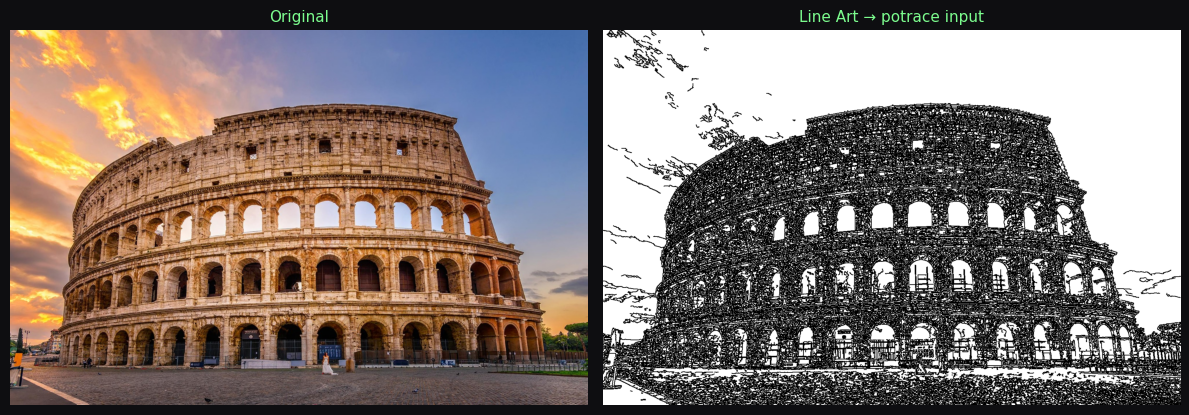

💡 Open the SVG in Inkscape / browser to view the vector result.


In [4]:
# 🔧 Adjust these:
MODE    = 'canny'   # 'canny' | 'adaptive' | 'xdog'
EPSILON = 1.0       # higher = fewer points (try 0.5 / 1.0 / 2.0 / 5.0)

svg_out = convert_image(IMAGE_PATH, mode=MODE, epsilon=EPSILON)

In [5]:
from google.colab import files
files.download(svg_out)
print('⬇️  Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download started!


## 🔬 Section 4 — Compare All 3 Line Art Modes

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#0e0e11')
orig = cv2.imread(IMAGE_PATH)
items = [('Original', None, '#aaaacc'),
         ('canny', 'canny', '#7cfc8e'),
         ('adaptive', 'adaptive', '#4af0c8'),
         ('xdog', 'xdog', '#ffbb55')]
for ax, (title, mode, color) in zip(axes, items):
    ax.set_facecolor('#17171c'); ax.axis('off')
    ax.set_title(title, color=color, fontsize=12)
    img = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB) if mode is None \
          else image_to_line_art(IMAGE_PATH, mode=mode)
    ax.imshow(img, cmap=None if mode is None else 'gray')
plt.tight_layout(); plt.show()

## 📄 Section 5 — PDF Multi-Image

In [ ]:
from google.colab import files
uploaded_pdf = files.upload()
PDF_PATH = list(uploaded_pdf.keys())[0]
zip_out = convert_pdf(PDF_PATH, mode='adaptive', epsilon=1.0)
files.download(zip_out)

---
## 📝 Quick Reference

| `mode` | Best for |
|--------|----------|
| `canny` | Photos, complex scenes |
| `adaptive` | Manuscripts, printed docs, sketches |
| `xdog` | Artistic / stylized look |

| `epsilon` | Effect |
|-----------|--------|
| `0.5` | Minimal simplification — keeps fine curves |
| `1.0` | Balanced (default) |
| `3.0` | Aggressive — good for clean geometric shapes |
| `5.0+` | Very coarse — small file, rough edges |